# Regression Modeling
We will demonstrate a full regression workflow using the California Housing dataset.

Models included:
- KNN Regressor
- Lasso Regression
- Support Vector Regressor
- XGBoost Regressor
- LightGBM Regressor
- SGD Regressor

### Objective function

$\sum (y-\hat{y})^2 = \sum \epsilon^2$

Workflow:
1. Load data
2. EDA focused on assumptions and modeling decisions
3. Build preprocessing and modeling pipelines
4. Evaluate baseline models
5. Tune hyperparameters
6. Select the best model
7. Compare performance visually

## 1. Import libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso, SGDRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


## 2. Load dataset
Using the California Housing dataset from scikit-learn.

## 📊 Feature Definitions (California Housing Dataset)

| Feature | Description |
|--------|-------------|
| **MedInc** | Median income of households in the block group (in tens of thousands of dollars) |
| **HouseAge** | Median age of houses in the block group (in years) |
| **AveRooms** | Average number of rooms per household |
| **AveBedrms** | Average number of bedrooms per household |
| **Population** | Total population in the block group |
| **AveOccup** | Average number of people per household |
| **Latitude** | Latitude coordinate of the block group |
| **Longitude** | Longitude coordinate of the block group |
| **MedHouseVal (Target)** | Median house value (in $100,000 units) |

---

### 🧠 Notes
- Each row represents a **block group in California**
- Some variables are **ratios** (e.g., `AveRooms`, `AveOccup`)
- Location (`Latitude`, `Longitude`) plays a **major role in house prices**
- The target variable is **scaled**, not raw price

In [30]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Basic overview

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 4. Missing values
We check this first because missing values affect preprocessing choices.

In [33]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 5. Target distribution
A skewed target can affect some models and evaluation behavior.

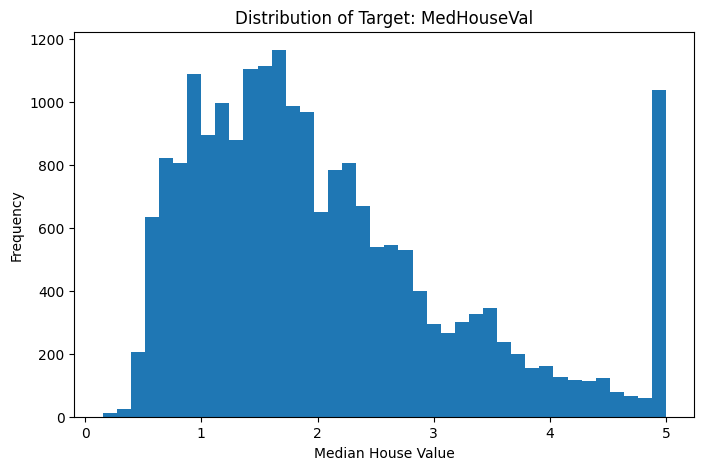

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=40)
plt.title("Distribution of Target: MedHouseVal")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

## 6. Feature distributions
This helps us inspect skewness and spread.

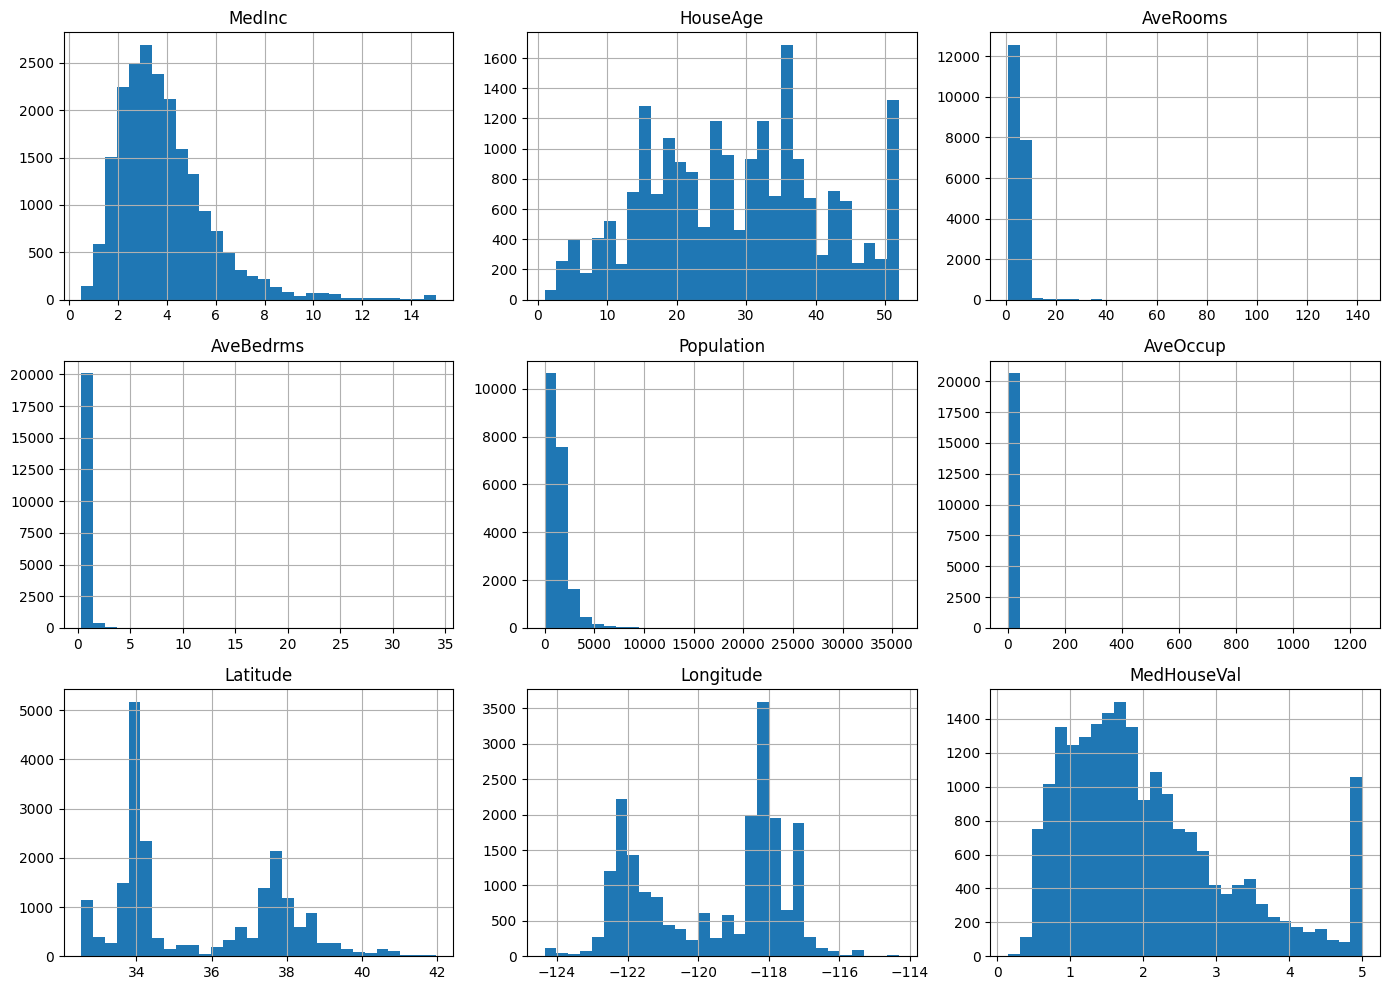

In [35]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

## 7. Correlation analysis
This helps us inspect linear relationships and possible multicollinearity.

In [36]:
corr = df.corr(numeric_only=True)
corr["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

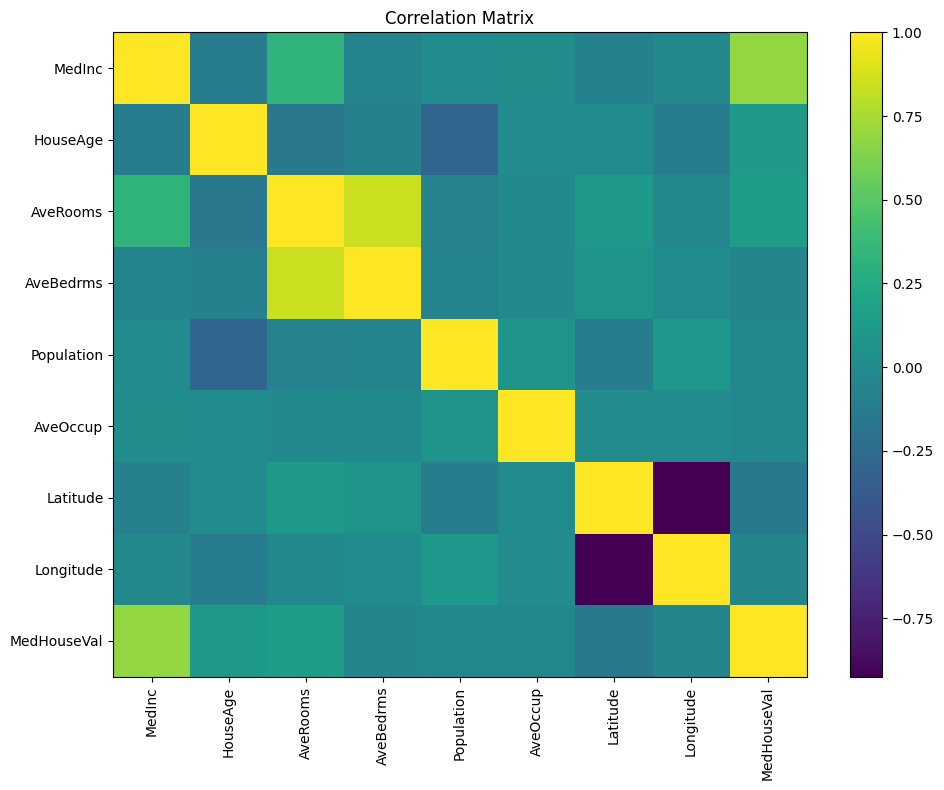

In [37]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Scatter plots for approximate linearity
This helps us judge whether linear models may work well.

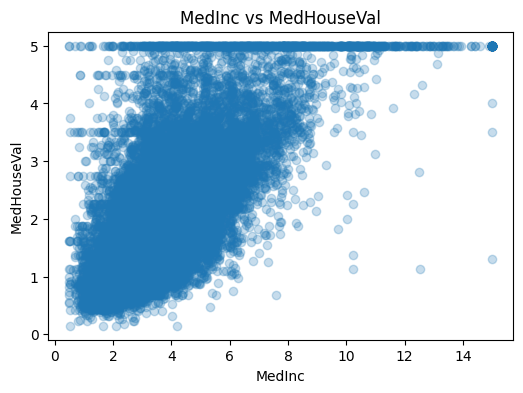

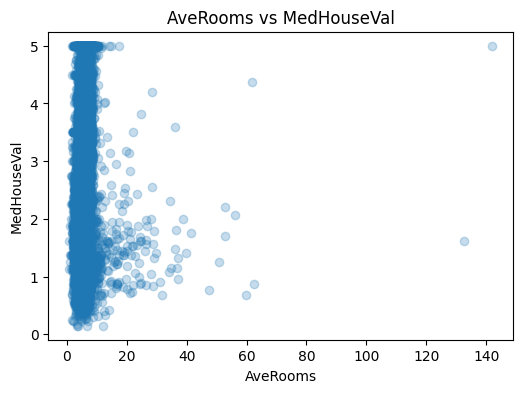

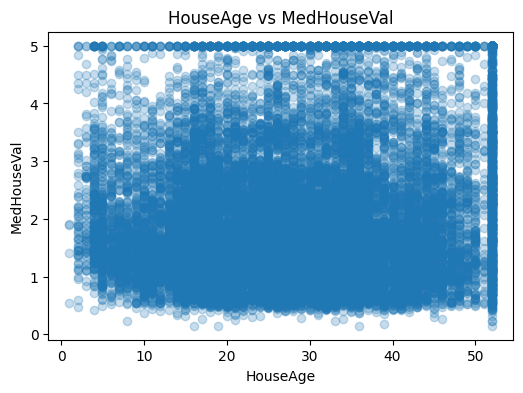

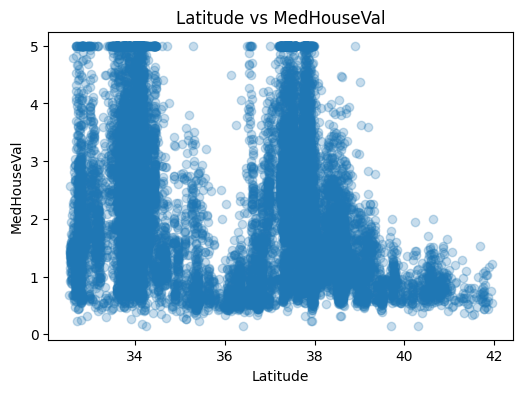

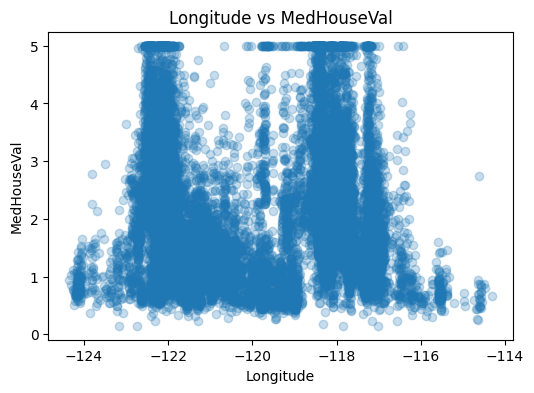

In [38]:
selected_features = ["MedInc", "AveRooms", "HouseAge", "Latitude", "Longitude"]

for col in selected_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df["MedHouseVal"], alpha=0.25)
    plt.title(f"{col} vs MedHouseVal")
    plt.xlabel(col)
    plt.ylabel("MedHouseVal")
    plt.show()

## 9. Outlier inspection with boxplots
Outliers can affect distance-based and linear models.

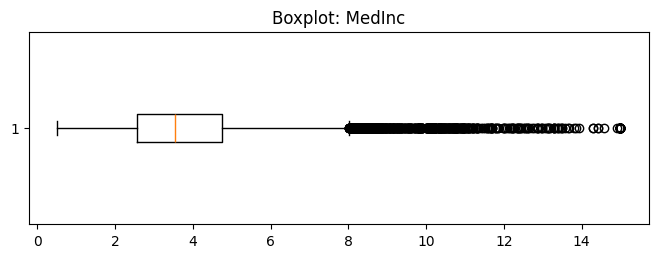

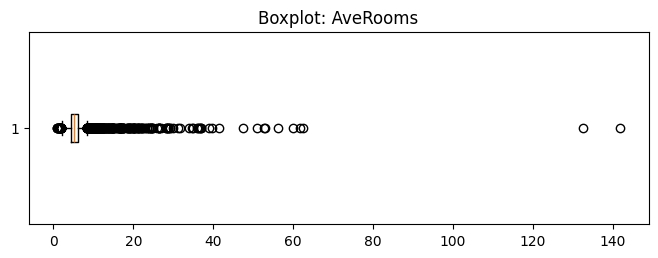

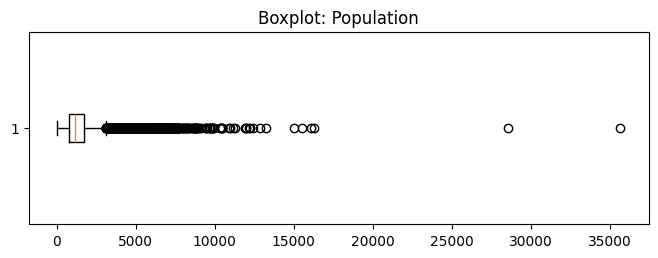

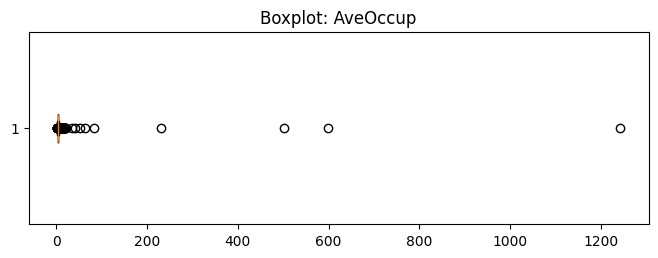

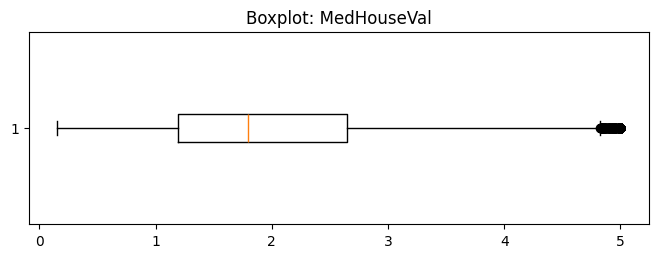

In [39]:
for col in ["MedInc", "AveRooms", "Population", "AveOccup", "MedHouseVal"]:
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot: {col}")
    plt.show()

## 10. Modeling note from EDA
What the EDA suggests:
- Features are on different scales, so scaling is necessary for KNN, SVR, Lasso, and SGD.
- Relationships are not purely linear, so tree-boosting models may perform better.
- Some features show skewness and outliers, so robust model comparison is important.

## 11. Train-test split

In [40]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X.columns.tolist()

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features)
])

preprocessor_tree = ColumnTransformer([
    ("num", tree_preprocessor, numeric_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


## 12. Build baseline model pipelines

In [41]:
models = {
    "KNN": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsRegressor())
    ]),
    "LASSO": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", Lasso(random_state=42, max_iter=5000))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", SVR())
    ]),
    "SGD": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", SGDRegressor(random_state=42, max_iter=2000, tol=1e-3))
    ])
}


models["XGBOOST"] = Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", XGBRegressor(
            random_state=42,
            objective="reg:squarederror",
            n_estimators=200,
            verbosity=0
        ))
])


models["LGBM"] = Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            random_state=42,
            n_estimators=200,
            verbose=-1
        ))
])

list(models.keys())

['KNN', 'LASSO', 'SVM', 'SGD', 'XGBOOST', 'LGBM']

## 13. Baseline cross-validation evaluation
Metrics:
- RMSE
- MAE
- R²

In [42]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

baseline_results = []

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_results.append({
        "Model": name,
        "CV_RMSE": -scores["test_rmse"].mean(),
        "CV_MAE": -scores["test_mae"].mean(),
        "CV_R2": scores["test_r2"].mean()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("CV_RMSE")
baseline_df

,Model,CV_RMSE,CV_MAE,CV_R2
5,LGBM,0.459270,0.303987,0.842042
4,XGBOOST,0.475836,0.315057,0.830463
2,SVM,0.592471,0.394176,0.737325
0,KNN,0.647638,0.443213,0.686141
1,LASSO,1.156186,0.913947,-0.000317
3,SGD,122.811343,7.820432,-27619.072169


## 14. Baseline model comparison plots

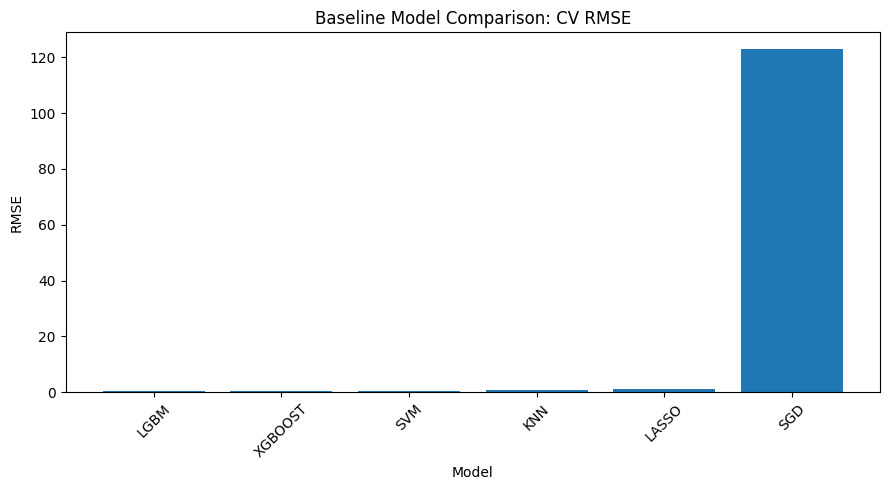

In [43]:
plt.figure(figsize=(9, 5))
plt.bar(baseline_df["Model"], baseline_df["CV_RMSE"])
plt.title("Baseline Model Comparison: CV RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

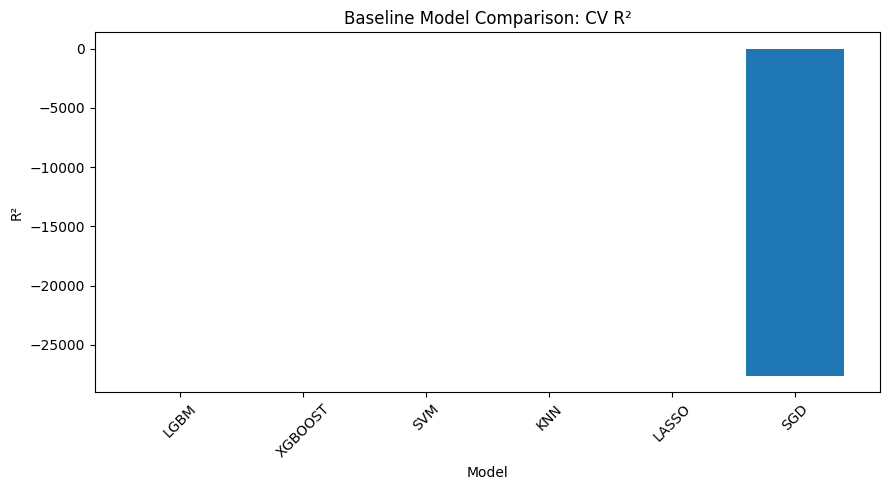

In [44]:
plt.figure(figsize=(9, 5))
plt.bar(baseline_df["Model"], baseline_df["CV_R2"])
plt.title("Baseline Model Comparison: CV R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Hyperparameter tuning
We use RandomizedSearchCV for each model.

In [45]:
param_grids = {
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },
    "LASSO": {
        "model__alpha": np.logspace(-4, 1, 20)
    },
    "SVM": {
        "model__C": [0.1, 1, 10, 50],
        "model__epsilon": [0.01, 0.05, 0.1, 0.2],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"]
    },
    "SGD": {
        "model__loss": ["squared_error", "huber"],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__alpha": np.logspace(-5, -1, 10),
        "model__learning_rate": ["optimal", "adaptive"],
        "model__eta0": [0.001, 0.01, 0.05, 0.1]
    }
}


param_grids["XGBOOST"] = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
}


param_grids["LGBM"] = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [-1, 5, 10],
        "model__subsample": [0.8, 1.0]
}

best_estimators = {}
tuning_summary = []

for name, pipe in models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=12,
        scoring="neg_root_mean_squared_error",
        cv=5,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_
    tuning_summary.append({
        "Model": name,
        "Best_CV_RMSE": -search.best_score_,
        "Best_Params": search.best_params_
    })

tuned_df = pd.DataFrame(tuning_summary).sort_values("Best_CV_RMSE")
tuned_df

Tuning KNN...
Tuning LASSO...
Tuning SVM...
Tuning SGD...
Tuning XGBOOST...
Tuning LGBM...


,Model,Best_CV_RMSE,Best_Params
5,LGBM,0.455134,"{'model__subsample': 0.8, 'model__num_leaves':..."
4,XGBOOST,0.463550,"{'model__subsample': 1.0, 'model__n_estimators..."
2,SVM,0.564475,"{'model__kernel': 'rbf', 'model__gamma': 'scal..."
0,KNN,0.599270,"{'model__weights': 'distance', 'model__p': 1, ..."
1,LASSO,0.720517,{'model__alpha': 0.0006158482110660267}
3,SGD,0.748016,"{'model__penalty': 'l1', 'model__loss': 'huber..."


## 16. Tuned model comparison plot

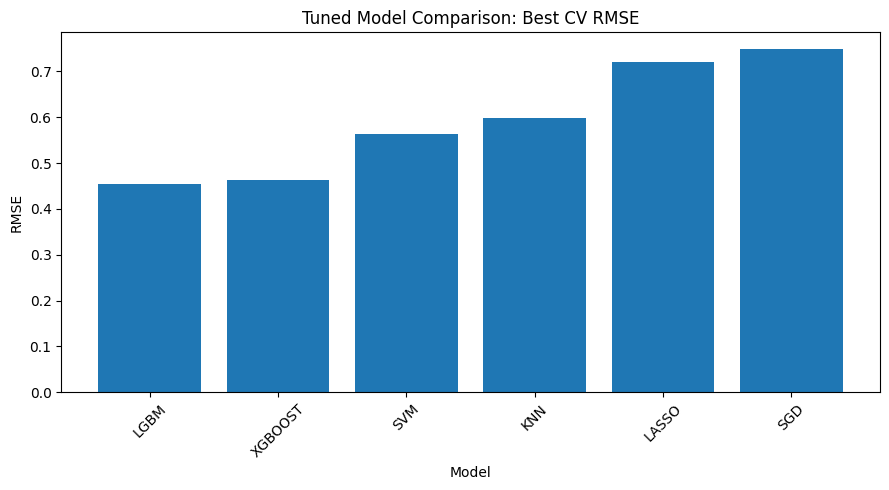

In [46]:
plt.figure(figsize=(9, 5))
plt.bar(tuned_df["Model"], tuned_df["Best_CV_RMSE"])
plt.title("Tuned Model Comparison: Best CV RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Final evaluation on the test set

In [47]:
final_results = []

for name, est in best_estimators.items():
    est.fit(X_train, y_train)
    preds = est.predict(X_test)

    final_results.append({
        "Model": name,
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "Test_MAE": mean_absolute_error(y_test, preds),
        "Test_R2": r2_score(y_test, preds)
    })

final_df = pd.DataFrame(final_results).sort_values("Test_RMSE")
final_df

,Model,Test_RMSE,Test_MAE,Test_R2
5,LGBM,0.443044,0.290967,0.850209
4,XGBOOST,0.457328,0.301966,0.840395
2,SVM,0.566809,0.379624,0.754830
0,KNN,0.603449,0.405802,0.722109
1,LASSO,0.744991,0.533161,0.576459
3,SGD,0.758064,0.524261,0.561464


## 18. Final performance plots

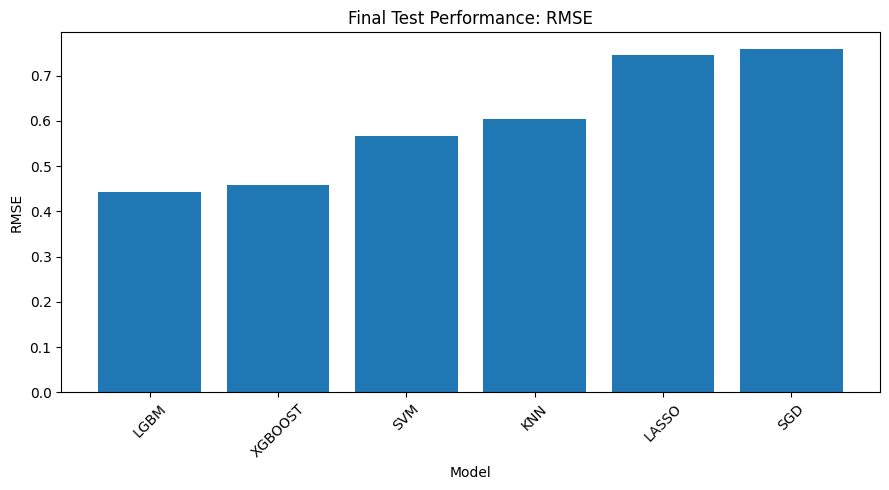

In [48]:
plt.figure(figsize=(9, 5))
plt.bar(final_df["Model"], final_df["Test_RMSE"])
plt.title("Final Test Performance: RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

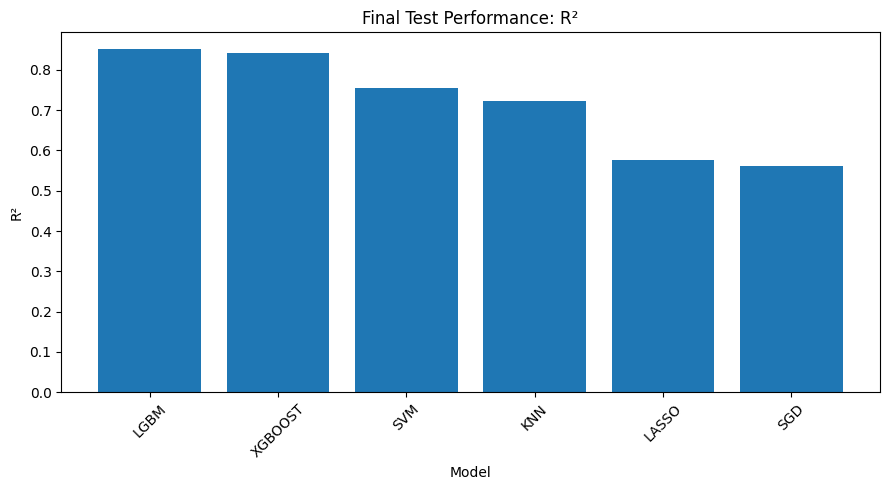

In [49]:
plt.figure(figsize=(9, 5))
plt.bar(final_df["Model"], final_df["Test_R2"])
plt.title("Final Test Performance: R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. Select the best model

In [50]:
best_model_name = final_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

print("Best model:", best_model_name)
best_model

Best model: LGBM


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

## 20. Actual vs predicted plot for the best model

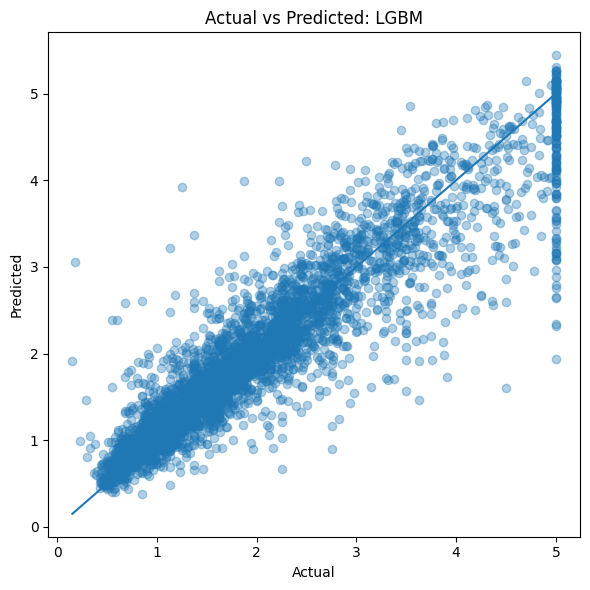

In [51]:
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.tight_layout()
plt.show()

## 21. Baseline vs tuned comparison

In [52]:
comparison_df = baseline_df.merge(
    tuned_df[["Model", "Best_CV_RMSE"]],
    on="Model",
    how="inner"
).sort_values("Best_CV_RMSE")

comparison_df

,Model,CV_RMSE,CV_MAE,CV_R2,Best_CV_RMSE
0,LGBM,0.459270,0.303987,0.842042,0.455134
1,XGBOOST,0.475836,0.315057,0.830463,0.463550
2,SVM,0.592471,0.394176,0.737325,0.564475
3,KNN,0.647638,0.443213,0.686141,0.599270
4,LASSO,1.156186,0.913947,-0.000317,0.720517
5,SGD,122.811343,7.820432,-27619.072169,0.748016


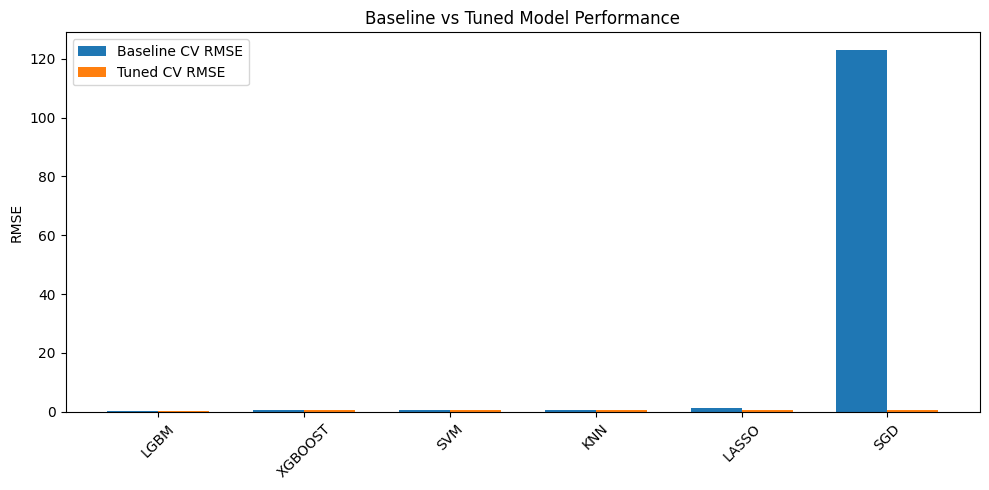

In [53]:
x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comparison_df["CV_RMSE"], width, label="Baseline CV RMSE")
plt.bar(x + width/2, comparison_df["Best_CV_RMSE"], width, label="Tuned CV RMSE")

plt.xticks(x, comparison_df["Model"], rotation=45)
plt.ylabel("RMSE")
plt.title("Baseline vs Tuned Model Performance")
plt.legend()
plt.tight_layout()
plt.show()

## 22. Optional: feature importance for tree-based best model
This section runs only if the best model is XGBoost or LightGBM.

      Feature  Importance
6    Latitude        1615
7   Longitude        1597
5    AveOccup        1181
0      MedInc        1122
2    AveRooms         936
4  Population         892
3   AveBedrms         838
1    HouseAge         819


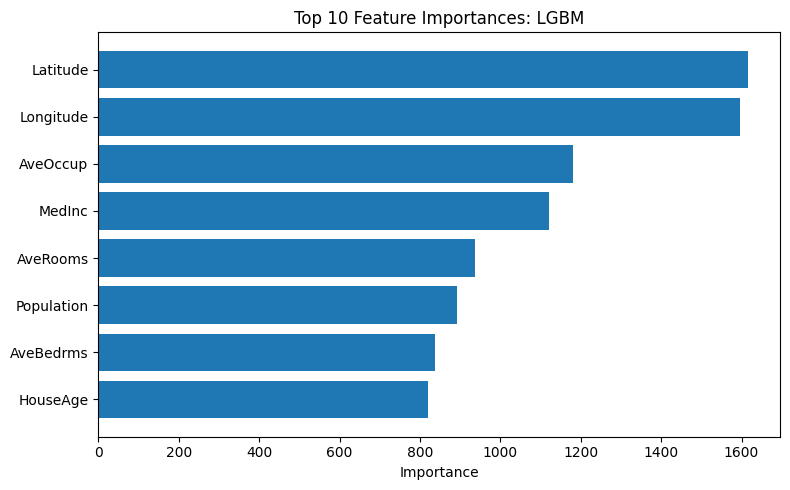

In [54]:
if best_model_name in ["XGBOOST", "LGBM"]:
    booster = best_model.named_steps["model"]
    importances = booster.feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print(feat_imp.head(10))

    plt.figure(figsize=(8, 5))
    plt.barh(feat_imp["Feature"].head(10)[::-1], feat_imp["Importance"].head(10)[::-1])
    plt.title(f"Top 10 Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Best model is not tree-based. Feature importance section skipped.")